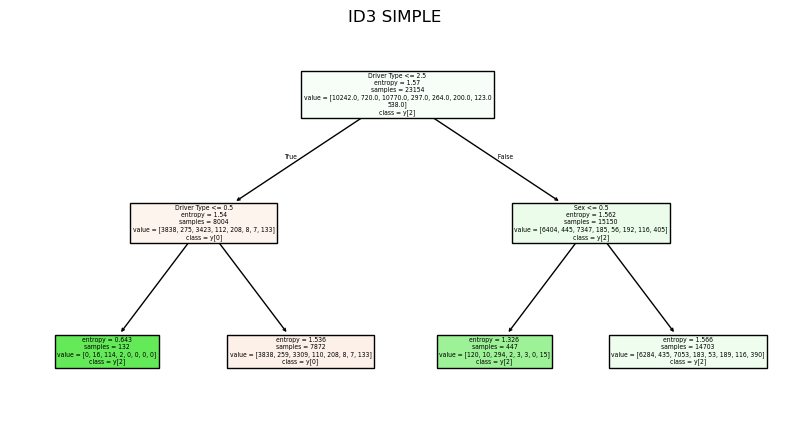

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("Public_Chauffeurs_20260405.csv")

df = df[['Driver Type', 'Sex', 'Status']]

for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop("Status", axis=1)
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2
)

model.fit(X_train, y_train)

plt.figure(figsize=(10,5))
plot_tree(model, feature_names=X.columns, class_names=True, filled=True)
plt.title("ID3 SIMPLE ")
plt.show()

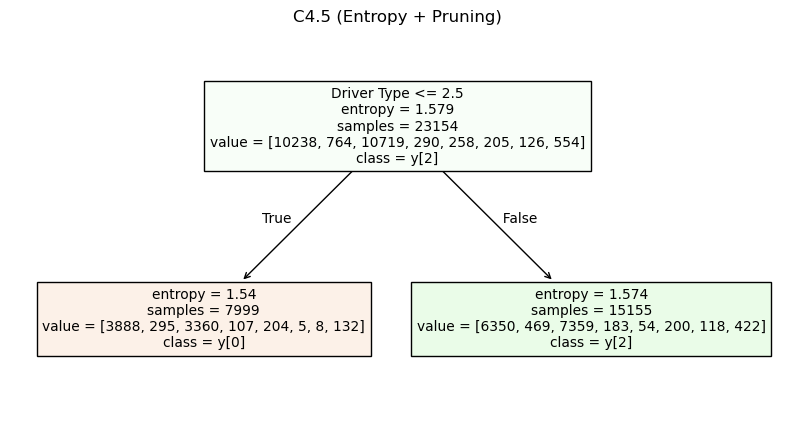

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Charger dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# Colonnes utiles
df = df[['Driver Type', 'Sex', 'Status']]

# Encodage
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# X / y
X = df.drop("Status", axis=1)
y = df["Status"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# C4.5 (approximation avec pruning)
model = DecisionTreeClassifier(
    criterion="entropy",   # comme ID3/C4.5
    max_depth=None,        # arbre libre
    ccp_alpha=0.01         # pruning = amélioration C4.5
)

# Apprentissage
model.fit(X_train, y_train)

# Affichage arbre
plt.figure(figsize=(10,5))
plot_tree(model, feature_names=X.columns, class_names=True, filled=True)

plt.title("C4.5 (Entropy + Pruning)")
plt.show()